In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

Load the Dataset

In [22]:
df=pd.read_csv("Unemployment in India.csv")

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [23]:
print(df.shape)

(768, 7)


In [24]:
df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


Exploratory Data Analysis (EDA)

In [26]:
# removing white space 
df.columns = df.columns.str.strip() 

In [27]:
df['Date'] = pd.to_datetime(df['Date'])


C:\Users\Janvi Panchal\AppData\Local\Temp\ipykernel_18228\3386729631.py:1: UserWarning:

Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.



In [28]:
df.rename(columns={
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation_Rate'
}, inplace=True)

df.dropna(inplace=True)

In [29]:
df.isnull().sum()

Region                       0
Date                         0
Frequency                    0
Unemployment_Rate            0
Estimated Employed           0
Labour_Participation_Rate    0
Area                         0
dtype: int64

EDA (Exploratory Data Analysis)

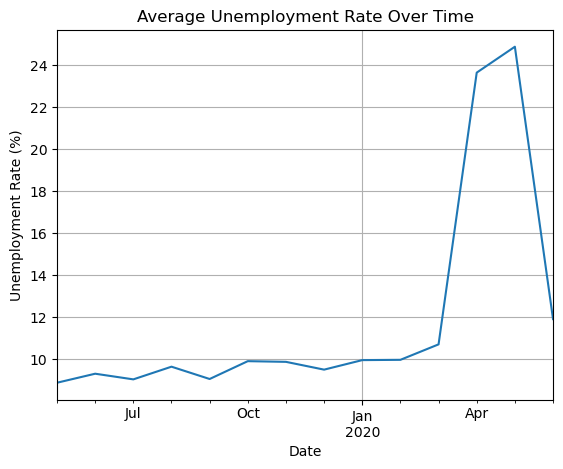

In [30]:
# Overall unemployment rate over time
df.groupby('Date')['Unemployment_Rate'].mean().plot()
plt.title('Average Unemployment Rate Over Time')
plt.ylabel('Unemployment Rate (%)')
plt.xlabel('Date')
plt.grid(True)
plt.show()

Region-Wise Analysis

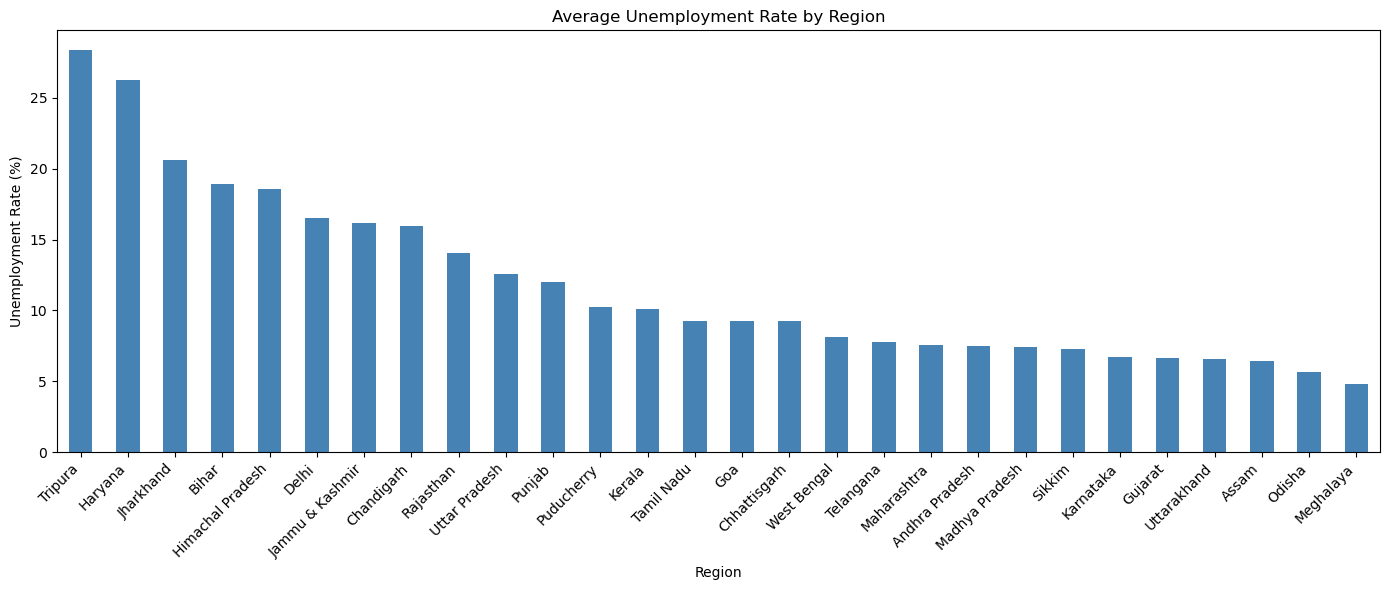

In [31]:
region_avg = df.groupby('Region')['Unemployment_Rate'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
region_avg.plot(kind='bar', color='steelblue')
plt.title('Average Unemployment Rate by Region')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("region_wise_unemployment.png", bbox_inches="tight")
plt.show()

Conclusion :
Tripura and Haryana had much higher Unemployment Rate than others and 
Meghalaya had the lowest

COVID-19 Impact Analysis

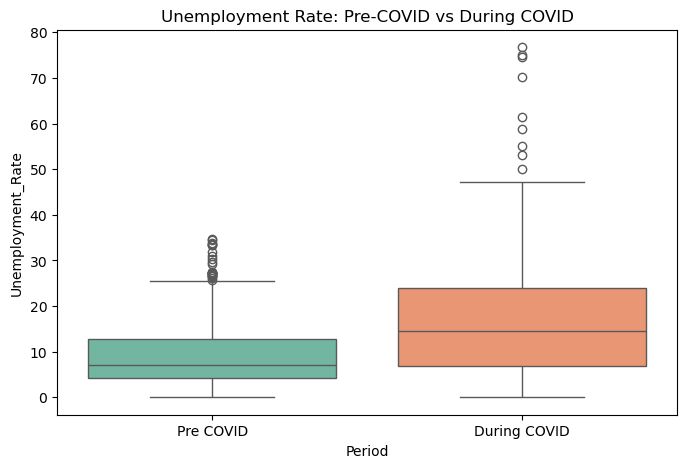

In [32]:
df['Period'] = df['Date'].apply(lambda x: 'During COVID' if x >= pd.to_datetime('2020-03-01') else 'Pre COVID')
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x='Period',
    y='Unemployment_Rate',
    hue='Period',
    palette='Set2',
    legend=False
)
plt.title('Unemployment Rate: Pre-COVID vs During COVID')
plt.savefig("covid_impact.png", bbox_inches="tight")
plt.show()

Conclusion: Pre COVID --> Unemployment Rate was low and stable but During COVID --> Unemployment Rate was high and spread out 

Correlation Heatmap

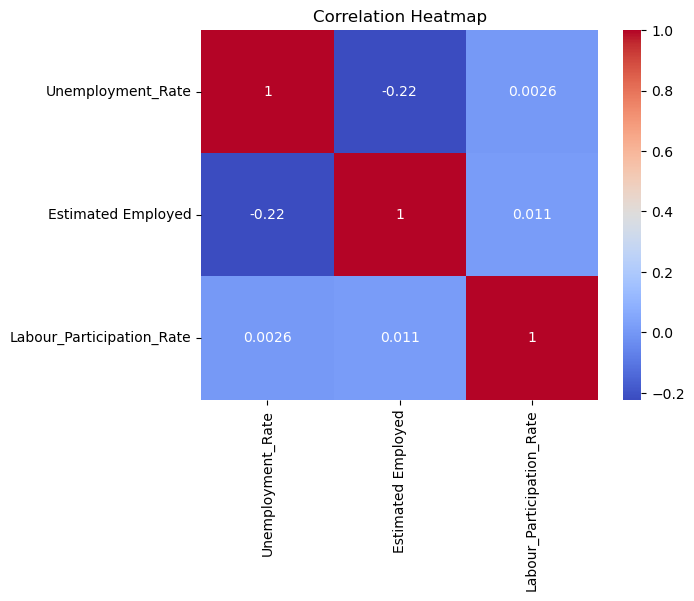

In [33]:
sns.heatmap(df[['Unemployment_Rate', 'Estimated Employed', 'Labour_Participation_Rate']].corr(),
            annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig("correlation_heatmap.png", bbox_inches="tight")
plt.show()

Interactive plot

In [34]:
import plotly.express as px

fig = px.line(df.groupby('Date')['Unemployment_Rate'].mean().reset_index(),
              x='Date', y='Unemployment_Rate',
              title='Unemployment Rate Over Time (Interactive)')
plt.savefig("unemployment_trend.png", bbox_inches="tight")
fig.show()

<Figure size 640x480 with 0 Axes>

Conclusion: The unemployment rate spiked sharply during COVID (March-May 2020)